# Preprocessing Pipeline
This notebook runs the full preprocessing pipeline end-to-end and documents each stage: daily preprocessing, EOM sampling, feature engineering, and target construction. It also saves intermediate panels in `stages/`.


## Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from params import OUT_DIR
from src.preprocessing.pipeline import build_feature_panel
from src.preprocessing.preprocessing import PreprocessConfig

STAGES_DIR = Path(OUT_DIR) / "stages"
RAW_PATH = STAGES_DIR / "panel_raw.parquet"
PREP_PATH = STAGES_DIR / "panel_preprocessed.parquet"
EOM_PATH = STAGES_DIR / "panel_eom.parquet"
FEAT_PATH = STAGES_DIR / "panel_features.parquet"
MODEL_PATH = STAGES_DIR / "panel_model_ready.parquet"


## Load raw panel


In [2]:
df_raw = pd.read_parquet(RAW_PATH)
print("Rows:", len(df_raw))
print("Date range:", df_raw["date"].min(), "→", df_raw["date"].max())
print("Tickers:", df_raw["ticker"].nunique())


Rows: 221854
Date range: 2006-01-03 00:00:00 → 2025-12-30 00:00:00
Tickers: 45


## Preprocessing motivation


We focus on two issues:
- Structural NaNs from lags and rolling windows (expected at the start of the sample).
- Outliers in fundamental ratios and growth rates (handled via clipping + winsorization).

In [3]:
nan_rate = df_raw.isna().mean().sort_values(ascending=False)
display(nan_rate.head(15))


delta_roe_yoy          0.083889
debt_to_equity         0.058300
mom_12m                0.055577
ip_yoy                 0.055090
cpi_yoy                0.055090
earnings_growth_yoy    0.049402
revenue_growth_yoy     0.049402
sma_200                0.040567
price_sma_200          0.040567
roe                    0.033820
mom_6m                 0.030020
mom_3m                 0.017241
interest_coverage      0.013265
volatility_60d         0.012373
CPIAUCSL               0.011629
dtype: float64

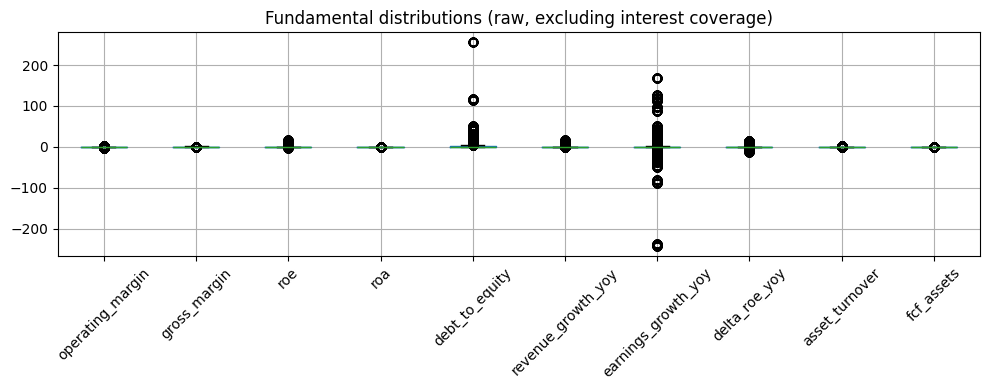

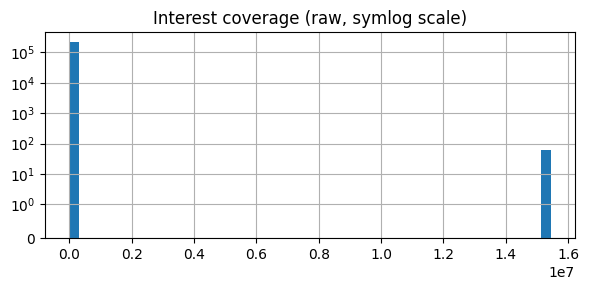

In [6]:
fund_cols = [
    'operating_margin',
    'gross_margin',
    'roe',
    'roa',
    'debt_to_equity',
    'revenue_growth_yoy',
    'earnings_growth_yoy',
    'delta_roe_yoy',
    'asset_turnover',
    'fcf_assets',
]
fund_cols = [c for c in fund_cols if c in df_raw.columns]

plt.figure(figsize=(10, 4))
df_raw[fund_cols].boxplot(rot=45)
plt.title('Fundamental distributions (raw, excluding interest coverage)')
plt.tight_layout()

if 'interest_coverage' in df_raw.columns:
    plt.figure(figsize=(6, 3))
    df_raw['interest_coverage'].hist(bins=50)
    plt.yscale('symlog', linthresh=1)
    plt.title('Interest coverage (raw, symlog scale)')
    plt.tight_layout()


- Macro series are official and smooth, so we do not clip or winsorize them; the main issue is release frequency, handled by forward-fill.
- Technicals (momentum, trend, volatility) naturally have fat tails; we keep them and rely on percentile ranks later, avoiding aggressive clipping.
- Fundamentals show extreme values due to accounting noise and small denominators.
  - Growth rates can go below -50% or above +200% when the prior quarter is very small or negative (base effects).
  - Debt-to-equity can explode when equity is small; values above typical bounds carry little incremental information.
  - Interest coverage can be huge when interest expense is near zero, so we visualize it separately on a symlog scale.

We therefore apply domain-aware clipping (e.g., growth in [-50%, +200%], leverage within a sensible range) and cross-sectional winsorization after EOM sampling. This stabilizes the tails without distorting the central cross-sectional ordering.


## Build pipeline outputs


This runs daily preprocessing, EOM sampling, feature engineering, and target construction in one pass, and stores all intermediate panels in `stages/`.

In [3]:
cfg = PreprocessConfig()

_ = build_feature_panel(
    df_raw,
    preprocess_config=cfg,
    preprocessed=False,
    add_target=True,
    drop_raws=False,
    save_stages=True,
    stages_dir=STAGES_DIR,
)
print("Saved stages to:", STAGES_DIR)


2026-02-23 23:33:35,238 | INFO | src.preprocessing.preprocessing | Preprocess panel: 221854 rows, 39 columns
2026-02-23 23:33:35,685 | INFO | src.preprocessing.preprocessing | Preprocess panel complete: 221854 rows, 39 columns
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/preprocessing/preprocessing.py:249: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return out.groupby(date_col, group_keys=False).apply(_clip_group)
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/preprocessing/preprocessing.py:249: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded 

Saved stages to: /Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/datasets/master_45t_20y/stages


## Load stage outputs


In [4]:
df_prep = pd.read_parquet(PREP_PATH)
df_eom = pd.read_parquet(EOM_PATH)
df_feat = pd.read_parquet(FEAT_PATH)
df_model = pd.read_parquet(MODEL_PATH)
print("preprocessed:", df_prep.shape)
print("eom:", df_eom.shape)
print("features:", df_feat.shape)
print("model_ready:", df_model.shape)


preprocessed: (221854, 39)
eom: (10587, 39)
features: (10587, 62)
model_ready: (10452, 26)


## Effects of preprocessing


### Preprocessing impact on NaNs

In [5]:
raw_nan = df_raw.isna().mean()
prep_nan = df_prep.isna().mean()

compare_cols = [
    "roe",
    "debt_to_equity",
    "interest_coverage",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "delta_roe_yoy",
    "CPIAUCSL",
    "INDPRO",
    "ip_yoy",
    "cpi_yoy",
    "mom_12m",
    "mom_6m",
    "mom_3m",
    "sma_200"
]
compare_cols = [c for c in compare_cols if c in df_raw.columns]

nan_compare = (
    pd.DataFrame({"raw": raw_nan, "preprocessed": prep_nan})
      .loc[compare_cols]
      .sort_values("raw", ascending=False)
)
display(nan_compare)


,raw,preprocessed
delta_roe_yoy,0.083889,0.083889
debt_to_equity,0.058300,0.058300
mom_12m,0.055577,0.055577
ip_yoy,0.055090,0.055090
cpi_yoy,0.055090,0.055090
revenue_growth_yoy,0.049402,0.049402
earnings_growth_yoy,0.049402,0.049402
sma_200,0.040567,0.040567
roe,0.033820,0.033820
mom_6m,0.030020,0.030020


The only noticeable drop is `CPIAUCSL`, because it benefits from macro forward‑fill once the first release is
available. The other NaN rates remain unchanged since they are structural: lags (macro and funds), sanity‑rule NaNs
(equity/interest conditions), and warm‑up windows for rolling/YoY features. These are expected and should not be
imputed beyond the neutral fill applied later to percentile‑ranked features.


### Preprocessing impact on fundamentals


We compare raw vs preprocessed distributions for a few key ratios to ensure that clipping 
reduces extreme tails without distorting central mass. The additional cross‑sectional winsorization
is applied later (post‑EOM), so its effect is visible in the engineered/model‑ready panels.

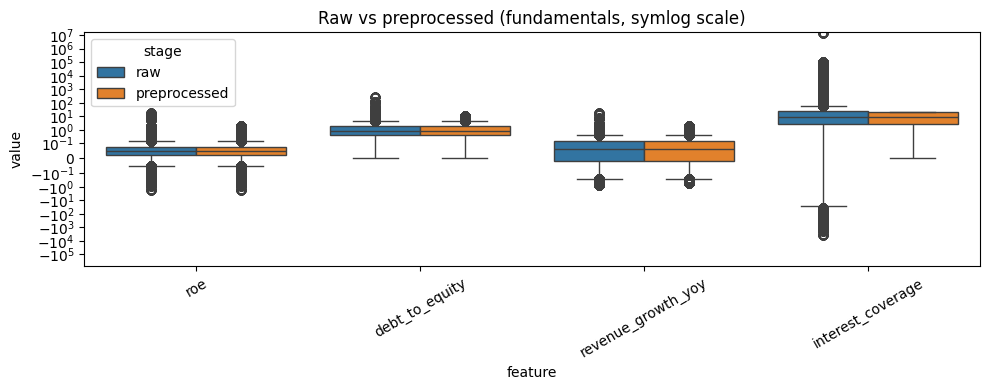

In [10]:
compare_features = [
    'roe',
    'debt_to_equity',
    'revenue_growth_yoy',
    "interest_coverage"
]
compare_features = [f for f in compare_features if f in df_raw.columns and f in df_prep.columns]

if compare_features:
    raw_slice = df_raw[compare_features].assign(stage='raw')
    prep_slice = df_prep[compare_features].assign(stage='preprocessed')
    plot_df = (
        pd.concat([raw_slice, prep_slice], ignore_index=True)
          .melt(id_vars='stage', var_name='feature', value_name='value')
    )
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=plot_df, x='feature', y='value', hue='stage')
    plt.yscale('symlog', linthresh=0.1)
    plt.title('Raw vs preprocessed (fundamentals, symlog scale)')
    plt.xticks(rotation=30)
    plt.tight_layout()
else:
    print('No shared features available for comparison')


### Growth features (tail focus)


Growth rates can have extreme tails due to base effects. We visualize them on a symmetric log scale
to compare raw vs preprocessed without hiding large outliers.

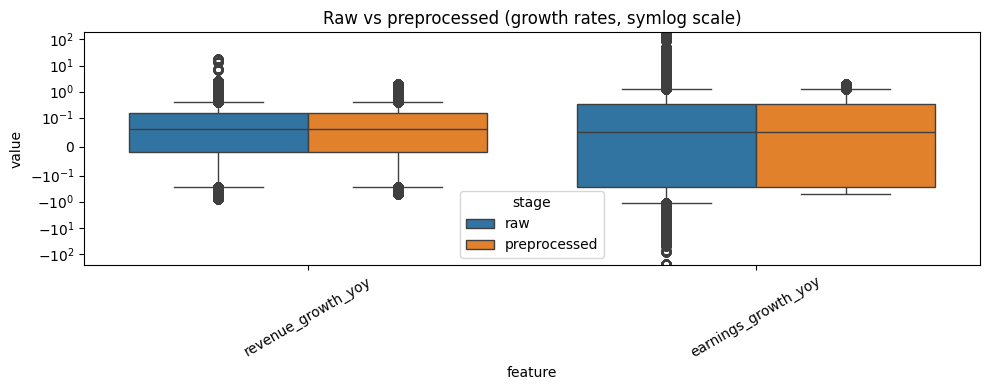

In [11]:
growth_compare = [
    'revenue_growth_yoy',
    'earnings_growth_yoy',
]
growth_compare = [g for g in growth_compare if g in df_raw.columns and g in df_prep.columns]

if growth_compare:
    raw_slice = df_raw[growth_compare].assign(stage='raw')
    prep_slice = df_prep[growth_compare].assign(stage='preprocessed')
    plot_df = (
        pd.concat([raw_slice, prep_slice], ignore_index=True)
          .melt(id_vars='stage', var_name='feature', value_name='value')
    )
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=plot_df, x='feature', y='value', hue='stage')
    plt.yscale('symlog', linthresh=0.1)
    plt.title('Raw vs preprocessed (growth rates, symlog scale)')
    plt.xticks(rotation=30)
    plt.tight_layout()
else:
    print('No growth features available for comparison')


## Effects of EOM sampling


EOM months: 2006-01 → 2025-12
Rows per month (min/median/max): 42 45.0 45


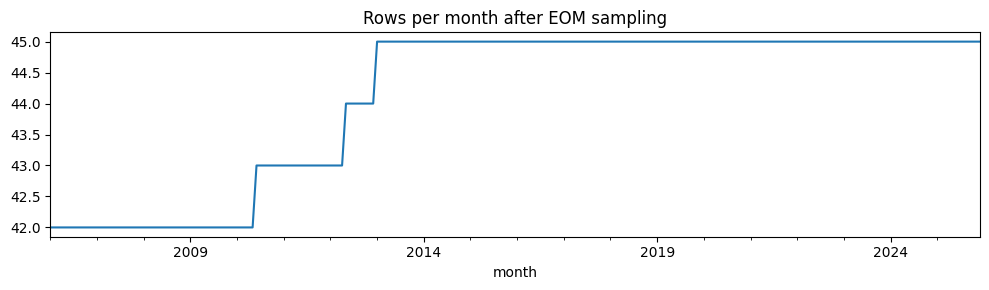

In [6]:
df_eom["month"] = pd.to_datetime(df_eom["date"]).dt.to_period("M")
rows_per_month = df_eom.groupby("month")["ticker"].count()
print("EOM months:", rows_per_month.index.min(), "→", rows_per_month.index.max())
print("Rows per month (min/median/max):", rows_per_month.min(), rows_per_month.median(), rows_per_month.max())
rows_per_month.plot(figsize=(10, 3), title="Rows per month after EOM sampling")
plt.tight_layout()


## Feature engineering effects


### Winsorization effect

We compare EOM values before vs after winsorization for a few key fundamentals to confirm tail trimming.


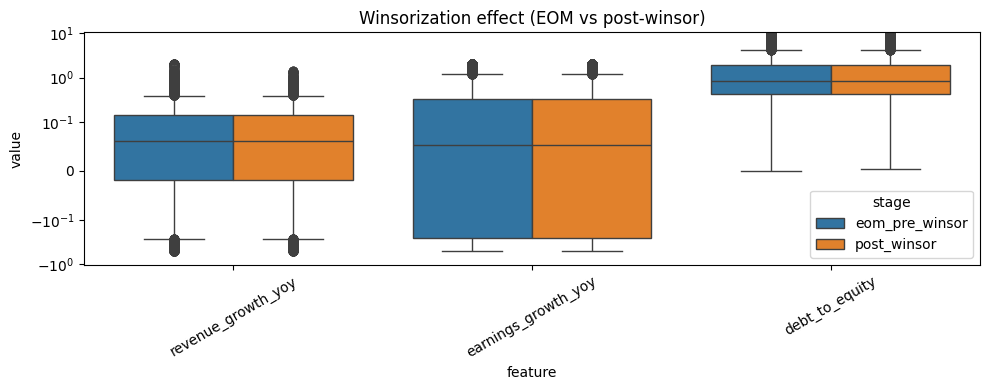

In [16]:
compare_cols = [
    'revenue_growth_yoy',
    'earnings_growth_yoy',
    'debt_to_equity',
]
compare_cols = [c for c in compare_cols if c in df_eom.columns and c in df_feat.columns]

if compare_cols:
    eom_slice = df_eom[compare_cols].assign(stage='eom_pre_winsor')
    feat_slice = df_feat[compare_cols].assign(stage='post_winsor')
    plot_df = (
        pd.concat([eom_slice, feat_slice], ignore_index=True)
          .melt(id_vars='stage', var_name='feature', value_name='value')
    )
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=plot_df, x='feature', y='value', hue='stage')
    plt.yscale('symlog', linthresh=0.1)
    plt.title('Winsorization effect (EOM vs post-winsor)')
    plt.xticks(rotation=30)
    plt.tight_layout()
else:
    print('No shared columns to compare winsorization effect')


### Macro regimes overview


We report the distribution of regimes to verify balanced coverage and temporal coherence.

macro_regime
deflation      0.312500
reflation      0.295833
goldilocks     0.258333
stagflation    0.133333
Name: proportion, dtype: float64

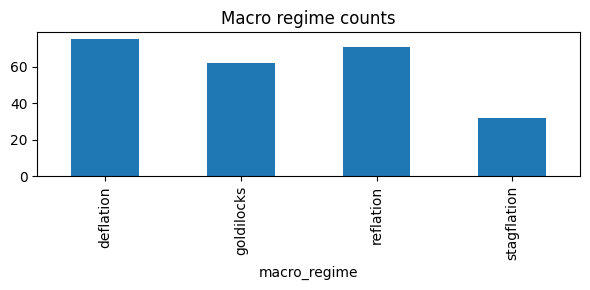

In [20]:
if 'macro_regime' in df_feat.columns:
    regime_counts = df_feat.groupby(df_feat['date'].dt.to_period('M'))['macro_regime'].first()
    display(regime_counts.value_counts(normalize=True))
    regime_counts.value_counts().sort_index().plot(kind='bar', figsize=(6, 3), title='Macro regime counts')
    plt.tight_layout()
else:
    print('macro_regime not available')


### Dominant regime by year


The yearly regimes look plausible (deflation around crisis years, reflation in recoveries).
Small mismatches vs. “real‑world labels” are normal because this is a simple rule‑based definition
using IP YoY and CPI YoY with a rolling threshold.


In [21]:
if 'macro_regime' in df_feat.columns:
    yearly_regime = (
        df_feat.assign(year=df_feat['date'].dt.year)
              .groupby('year')['macro_regime']
              .agg(lambda s: s.value_counts().idxmax())
    )
    display(yearly_regime)
else:
    print('macro_regime not available')


year
2006      deflation
2007     goldilocks
2008    stagflation
2009      deflation
2010     goldilocks
2011      reflation
2012      reflation
2013     goldilocks
2014     goldilocks
2015      deflation
2016      deflation
2017      reflation
2018      reflation
2019    stagflation
2020      deflation
2021      reflation
2022      reflation
2023      deflation
2024      deflation
2025     goldilocks
Name: macro_regime, dtype: category
Categories (4, object): ['deflation', 'goldilocks', 'reflation', 'stagflation']

### Percentile Ranking Features

In [7]:
engineered_cols = [c for c in df_feat.columns if c.endswith("_pr")]
print("Engineered PR features:", engineered_cols)

missing_engineered = df_feat[engineered_cols].isna().mean().sort_values(ascending=False)
display(missing_engineered.head(10))


Engineered PR features: ['roe_pr', 'roa_pr', 'operating_margin_pr', 'gross_margin_pr', 'revenue_growth_pr', 'earnings_growth_pr', 'delta_roe_pr', 'debt_pr', 'interest_coverage_pr', 'asset_turnover_pr', 'fcf_assets_pr', 'mom12_pr', 'mom6_pr', 'mom3_pr', 'trend_ratio_pr', 'vol_pr', 'vol_ratio_pr']


roe_pr                  0.0
asset_turnover_pr       0.0
vol_pr                  0.0
trend_ratio_pr          0.0
mom3_pr                 0.0
mom6_pr                 0.0
mom12_pr                0.0
fcf_assets_pr           0.0
interest_coverage_pr    0.0
roa_pr                  0.0
dtype: float64

Percentile‑rank features are computed cross‑sectionally and then filled with 0.5 for any missing
observations. This makes the PR features dense and treats missing values as neutral (median) rather than
dropping rows or injecting bias.


### Percentile ranking example


We show how percentile ranks normalize a feature cross‑sectionally within a month.

In [8]:
example_col = 'roe'
example_pr = 'roe_pr'
if example_col in df_feat.columns and example_pr in df_feat.columns:
    month = df_feat['date'].dt.to_period('M').min()
    snap = df_feat[df_feat['date'].dt.to_period('M') == month][[example_col, example_pr]]
    print(f'Example month: {month}')
    display(snap.sort_values(example_pr).head(10))
    display(snap.sort_values(example_pr).tail(10))
else:
    print('Example feature not available for percentile rank demo')


Example month: 2006-01


,roe,roe_pr
2,-0.004076,0.045455
13,-0.002485,0.090909
11,0.001495,0.136364
12,0.002555,0.181818
29,0.023770,0.227273
9,0.023802,0.272727
32,0.026534,0.318182
1,0.043072,0.363636
15,0.043350,0.409091
40,0.047558,0.454545


,roe,roe_pr
20,0.050661,0.590909
0,0.057594,0.636364
28,0.061277,0.681818
35,0.066770,0.727273
8,0.076247,0.772727
19,0.077635,0.818182
37,0.091764,0.863636
41,0.091946,0.909091
34,0.097799,0.954545
3,1.600538,1.000000


## Target construction


### Missing Target Values

Missing target_3m: 0.0
Missing target_1m: 0.0


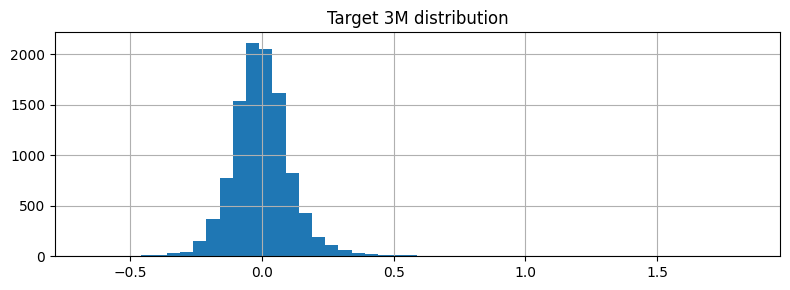

In [9]:
print("Missing target_3m:", df_model["target_3m"].isna().mean())
print("Missing target_1m:", df_model["target_1m"].isna().mean())

ax = df_model["target_3m"].hist(bins=50, figsize=(8, 3))
ax.set_title("Target 3M distribution")
plt.tight_layout()


### Target behavior by quantile


We check that higher target scores correspond to higher forward returns.

,target_3m,fwd_ret_3m
q,,
0,-0.148319,-0.105377
1,-0.056465,-0.012127
2,-0.006432,0.033174
3,0.045433,0.081159
4,0.165775,0.199765


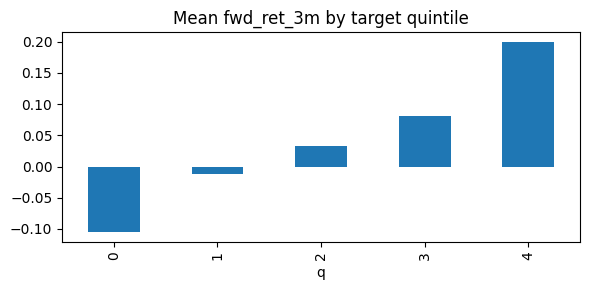

In [10]:
tmp = df_model.dropna(subset=['target_3m', 'fwd_ret_3m']).copy()
tmp['q'] = pd.qcut(tmp['target_3m'], 5, labels=False)
summary = tmp.groupby('q')[['target_3m', 'fwd_ret_3m']].mean()
display(summary)
summary['fwd_ret_3m'].plot(kind='bar', figsize=(6, 3), title='Mean fwd_ret_3m by target quintile')
plt.tight_layout()


## Model-ready inspection


### Feature coverage by ticker


This highlights the few early‑sample macro NaNs (pre‑first release).

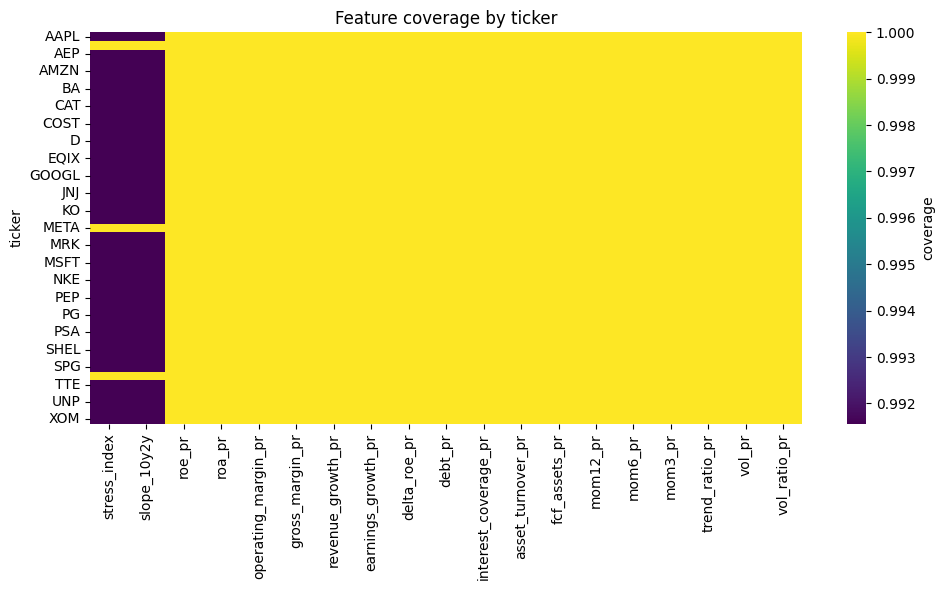

In [17]:
feature_cols = [
    c for c in df_model.columns
    if c not in {
        'date', 'ticker',
        'target_3m', 'target_1m',
        'fwd_ret_1m', 'fwd_ret_3m', 'fwd_ret_6m',
        'macro_regime',
    }
]
coverage = df_model.groupby('ticker')[feature_cols].apply(lambda x: x.notna().mean())
plt.figure(figsize=(10, 6))
sns.heatmap(coverage, cmap='viridis', cbar_kws={'label': 'coverage'})
plt.title('Feature coverage by ticker')
plt.tight_layout()


Why a few macro NaNs remain: they occur only in the very first months before the first macro release
(and before any lagged value exists to forward‑fill). This is expected and does not affect training materially.


### Feature correlation

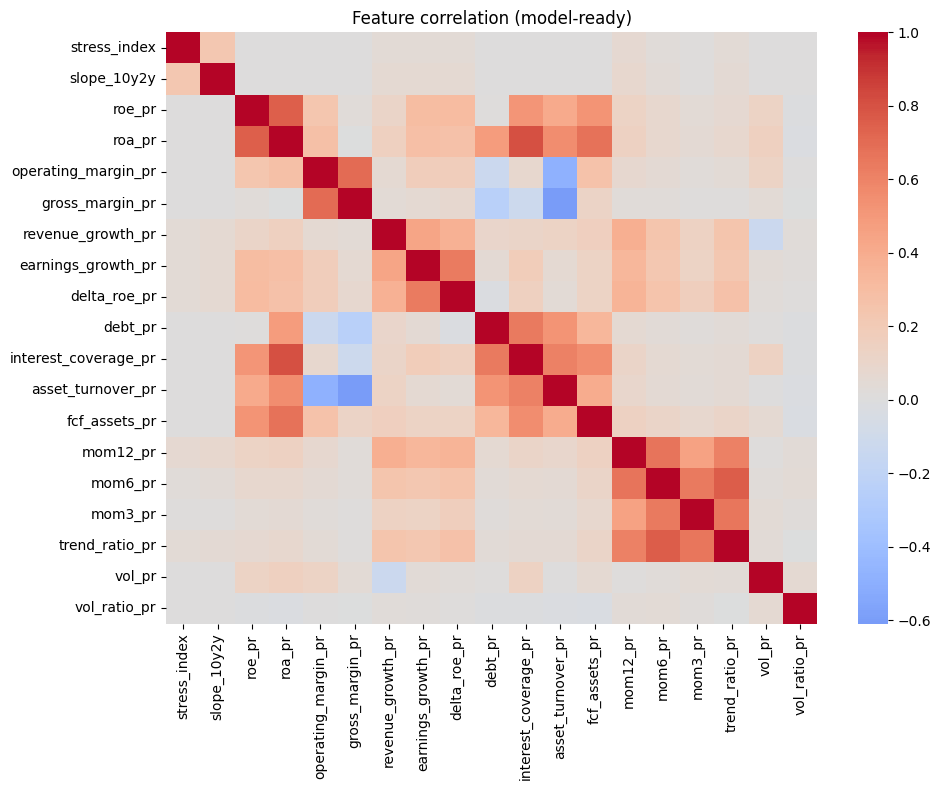

In [ ]:
corr = df_model[feature_cols].select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation (model-ready)')
plt.tight_layout()


### Highly correlated feature pairs


In [13]:
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'corr'})
        .assign(abs_corr=lambda d: d['corr'].abs())
)
corr_pairs = corr_pairs[corr_pairs['abs_corr'] >= 0.5]
corr_pairs = corr_pairs.sort_values('abs_corr', ascending=False)
corr_pairs['suggested_drop'] = np.where(corr_pairs['abs_corr'] >= 0.75, corr_pairs['feature_b'], '')
display(corr_pairs.head(20))


,feature_a,feature_b,corr,abs_corr,suggested_drop
183,interest_coverage_pr,roa_pr,0.809416,0.809416,roa_pr
63,roa_pr,interest_coverage_pr,0.809416,0.809416,interest_coverage_pr
302,trend_ratio_pr,mom6_pr,0.760553,0.760553,mom6_pr
267,mom6_pr,trend_ratio_pr,0.760553,0.760553,trend_ratio_pr
38,roe_pr,roa_pr,0.753937,0.753937,roa_pr
56,roa_pr,roe_pr,0.753937,0.753937,roe_pr
76,operating_margin_pr,gross_margin_pr,0.708005,0.708005,
94,gross_margin_pr,operating_margin_pr,0.708005,0.708005,
65,roa_pr,fcf_assets_pr,0.676253,0.676253,
219,fcf_assets_pr,roa_pr,0.676253,0.676253,


Note: any feature drop decision should happen before model training, not in preprocessing.
Here we only diagnose redundancy; the actual feature set can be chosen per model/experiment.

### Correlation with target_3m

We compute Pearson correlation between each feature and the target to get a quick relevance signal.


In [14]:
if 'target_3m' in df_model.columns:
    feature_numeric = df_model[feature_cols].select_dtypes(include='number')
    target_corr = feature_numeric.corrwith(df_model['target_3m']).sort_values(key=lambda s: s.abs(), ascending=False)
    display(target_corr)
else:
    print('target_3m not available')


vol_pr                 -1.083369e-01
revenue_growth_pr       4.689722e-02
asset_turnover_pr       4.165266e-02
operating_margin_pr    -3.253405e-02
fcf_assets_pr           3.002123e-02
trend_ratio_pr          2.932608e-02
debt_pr                 2.234812e-02
mom6_pr                 2.124286e-02
roe_pr                 -2.097814e-02
gross_margin_pr        -1.908201e-02
vol_ratio_pr           -1.526678e-02
interest_coverage_pr   -1.036224e-02
roa_pr                 -8.871261e-03
earnings_growth_pr     -5.579040e-03
mom3_pr                 4.121129e-03
delta_roe_pr            4.070263e-03
mom12_pr                6.342154e-04
stress_index            1.787933e-17
slope_10y2y             4.616726e-18
dtype: float64

We compute per‑month Spearman IC between each feature and `target_3m`, then report the mean IC.


In [16]:
ic_results = {}
if 'target_3m' in df_model.columns:
    feature_numeric = df_model[feature_cols].select_dtypes(include='number')
    for col in feature_numeric.columns:
        ic_by_month = (
            df_model[[col, 'target_3m', 'date']]
            .dropna()
            .groupby(df_model['date'].dt.to_period('M'))
            .apply(
                lambda g: g[col].corr(g['target_3m'], method='spearman')
                if g[col].nunique() > 1 and g['target_3m'].nunique() > 1
                else np.nan
            )
        )
        ic_results[col] = ic_by_month.mean()
    ic_series = pd.Series(ic_results).sort_values(key=lambda s: s.abs(), ascending=False)
    display(ic_series)
else:
    print('target_3m not available')


vol_pr                 -0.071706
fcf_assets_pr           0.043243
revenue_growth_pr       0.043204
asset_turnover_pr       0.028597
vol_ratio_pr           -0.027007
delta_roe_pr            0.026962
debt_pr                 0.025667
trend_ratio_pr          0.025280
mom6_pr                 0.017166
roa_pr                  0.009838
roe_pr                 -0.008154
mom12_pr                0.007848
earnings_growth_pr      0.006126
operating_margin_pr    -0.004535
mom3_pr                -0.004466
interest_coverage_pr    0.002432
gross_margin_pr         0.000469
stress_index                 NaN
slope_10y2y                  NaN
dtype: float64

Low Pearson correlations and IC values are expected in cross‑sectional equity prediction. The signal‑to‑noise
ratio is naturally small, especially with monthly targets and de‑meaned returns. Our features are percentile‑ranked,
so relationships are often monotone but weak in linear terms.

Macro variables show NaN IC because they are constant across tickers within each month, so the cross‑sectional
correlation is undefined. Overall, small but stable ICs are typical; the goal is not large single‑feature signals
but a robust multivariate ranking.


### Macro time‑series correlation (market average)


We correlate macro variables with the **cross‑sectional average** forward return each month. This is a time‑series check for macro/overlay relevance.

In [35]:
macro_ts_cols = [c for c in ['stress_index', 'slope_10y2y'] if c in df_model.columns]
if macro_ts_cols:
    monthly = (
        df_model.assign(month=df_model['date'].dt.to_period('M'))
        .groupby('month')
        .agg({**{c: 'first' for c in macro_ts_cols}, 'fwd_ret_3m': 'mean'})
    )
    ts_corr = monthly[macro_ts_cols].corrwith(monthly['fwd_ret_3m']).sort_values(key=lambda s: s.abs(), ascending=False)
    display(ts_corr)
else:
    print('No macro columns available for time-series correlation')


stress_index   -0.018331
slope_10y2y    -0.015130
dtype: float64

Interpretation: these are time‑series correlations between each macro variable and the monthly average
forward return. The small negative values (around −0.02) indicate a very weak inverse relation: slightly lower
average returns when stress is higher or the curve is flatter/inverted. The magnitude is tiny, so this is a
contextual signal only, not a standalone predictor.


## Outputs

The pipeline saves the following artifacts in `stages/`:
- `panel_raw.parquet`
- `panel_preprocessed.parquet`
- `panel_eom.parquet`
- `panel_features.parquet`
- `panel_model_ready.parquet`
